<a href="https://colab.research.google.com/github/abdul30aijaz/Flood-Detection/blob/main/02_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - K-Means Clustering

This notebook groups observations using the eight scaled environmental features prepared in notebook 01. The flood outcome is excluded from clustering so the groups are based on environmental patterns rather than the answer. Run notebook 01 first and use its real processed CSV; this notebook does not generate data.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from pathlib import Path

# Configure project paths and clustering settings here so the rest of the notebook uses one configuration.
# Set PROJECT_ROOT_OVERRIDE to the path of your project in Google Drive, e.g., '/content/drive/MyDrive/your_project_name'
PROJECT_ROOT_OVERRIDE = "/content/drive/My Drive/Flood Detection"
PROJECT_MARKERS = ("data", "models", "notebooks")


def find_project_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        candidate = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if all((candidate / marker).is_dir() for marker in PROJECT_MARKERS):
            return candidate
        raise FileNotFoundError(
            f"PROJECT_ROOT_OVERRIDE does not contain the project folders: {candidate}"
        )

    start_path = Path.cwd().resolve()
    for candidate in (start_path, *start_path.parents):
        if all((candidate / marker).is_dir() for marker in PROJECT_MARKERS):
            return candidate
    raise FileNotFoundError(
        f"Project root not found from kernel directory {start_path}. "
        "Set PROJECT_ROOT_OVERRIDE to a project path visible to this kernel. "
        "A remote kernel needs the project files mounted or copied into its filesystem."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "flood_data_processed.csv"
KMEANS_MODEL_PATH = PROJECT_ROOT / "models" / "kmeans_model.joblib"
FEATURE_COLUMNS_PATH = PROJECT_ROOT / "models" / "feature_columns.json"
ENVIRONMENTAL_FEATURES = [
    "rainfall",
    "soil_moisture",
    "humidity",
    "ndvi",
    "ndwi",
    "elevation",
    "slope",
    "temperature",
]
TARGET_COLUMN = "flood_label"
CLUSTER_COLUMN = "cluster_label"
CLUSTER_COUNT = 3
RANDOM_STATE = 42
SELECTION_SAMPLE_SIZE = 2000

## Load and Validate Prepared Data

The Stage 1 output should contain scaled numeric environmental columns and `flood_label`. We drop any old `cluster_label` before fitting so rerunning this notebook replaces the previous assignments instead of clustering on them.

In [8]:
# Load the real Stage 1 output, verify its required columns, and prepare environmental inputs without the target.
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

if not PROCESSED_DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Prepared data not found at {PROCESSED_DATA_PATH}. Download a real dataset and complete notebook 01 first."
    )

df = pd.read_csv(PROCESSED_DATA_PATH)
required_columns = ENVIRONMENTAL_FEATURES + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Processed data is missing required columns: {missing_columns}. Review notebook 01.")

df = df.drop(columns=[CLUSTER_COLUMN], errors="ignore").copy()
feature_data = df[ENVIRONMENTAL_FEATURES].apply(pd.to_numeric, errors="coerce")
if feature_data.isna().any().any():
    raise ValueError("Environmental features contain missing or non-numeric values. Clean them in notebook 01 before clustering.")
if not np.isfinite(feature_data.to_numpy()).all():
    raise ValueError("Environmental features contain infinite values. Clean them in notebook 01 before clustering.")
if len(feature_data) < CLUSTER_COUNT:
    raise ValueError(f"K-Means with k={CLUSTER_COUNT} requires at least {CLUSTER_COUNT} rows.")

print(f"Loaded {len(df)} rows and {len(ENVIRONMENTAL_FEATURES)} environmental features.")
print("Clustering inputs (flood_label excluded):", ENVIRONMENTAL_FEATURES)

Loaded 3000 rows and 8 environmental features.
Clustering inputs (flood_label excluded): ['rainfall', 'soil_moisture', 'humidity', 'ndvi', 'ndwi', 'elevation', 'slope', 'temperature']


## Compare Candidate Cluster Counts

The elbow curve shows how within-cluster sum of squares (inertia) falls as k grows; a bend suggests diminishing returns. The silhouette score compares how close points are to their own cluster versus neighboring clusters; higher is better. These are diagnostics, not automatic decisions: this project proceeds with k=3 because its three groups are intended to represent low, medium, and high relative environmental risk. If the diagnostics disagree, record that limitation rather than changing k silently. For speed and reproducibility, diagnostics use a fixed-seed sample of up to 10,000 rows.

,k,inertia,silhouette
0,2,13562.034273,0.136412
1,3,12452.669557,0.121904
2,4,11499.428452,0.120151
3,5,10654.275595,0.120243
4,6,10084.643521,0.113261


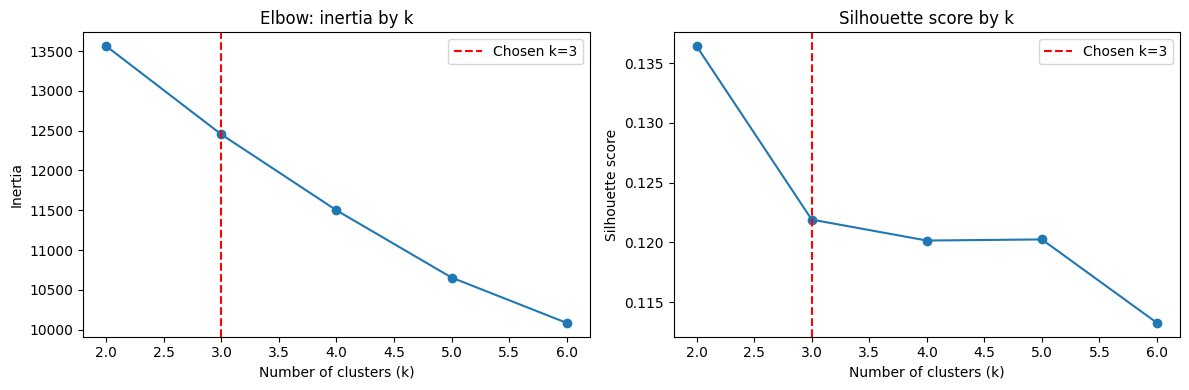

Highest sampled silhouette: k=2, score=0.136
The next step still fits k=3 to match the project's three risk bands.


In [9]:
# Compare inertia and silhouette scores on a reproducible sample before fitting the project-required three clusters.
sample_size = min(SELECTION_SAMPLE_SIZE, len(feature_data))
sample_positions = np.random.default_rng(RANDOM_STATE).choice(
    len(feature_data), size=sample_size, replace=False
)
selection_data = feature_data.iloc[sample_positions].to_numpy()
candidate_ks = list(range(2, min(6, sample_size - 1) + 1))
if not candidate_ks:
    raise ValueError("At least three rows are needed to compare candidate cluster counts.")

selection_results = []
for candidate_k in candidate_ks:
    candidate_model = KMeans(
        n_clusters=candidate_k, random_state=RANDOM_STATE, n_init=10
    )
    candidate_labels = candidate_model.fit_predict(selection_data)
    if len(np.unique(candidate_labels)) < 2:
        candidate_silhouette = np.nan
    else:
        candidate_silhouette = silhouette_score(selection_data, candidate_labels)
    selection_results.append(
        {"k": candidate_k, "inertia": candidate_model.inertia_, "silhouette": candidate_silhouette}
    )

selection_table = pd.DataFrame(selection_results)
display(selection_table)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(selection_table["k"], selection_table["inertia"], marker="o")
axes[0].axvline(CLUSTER_COUNT, color="red", linestyle="--", label="Chosen k=3")
axes[0].set(title="Elbow: inertia by k", xlabel="Number of clusters (k)", ylabel="Inertia")
axes[0].legend()
axes[1].plot(selection_table["k"], selection_table["silhouette"], marker="o")
axes[1].axvline(CLUSTER_COUNT, color="red", linestyle="--", label="Chosen k=3")
axes[1].set(title="Silhouette score by k", xlabel="Number of clusters (k)", ylabel="Silhouette score")
axes[1].legend()
figure.tight_layout()
plt.show()

best_silhouette_row = selection_table.loc[selection_table["silhouette"].idxmax()]
print(f"Highest sampled silhouette: k={int(best_silhouette_row['k'])}, score={best_silhouette_row['silhouette']:.3f}")
print("The next step still fits k=3 to match the project's three risk bands.")

## Compare Candidate Cluster Counts

The elbow curve shows how within-cluster sum of squares (inertia) falls as k grows; a bend suggests diminishing returns. The silhouette score compares how close points are to their own cluster versus neighboring clusters; higher is better. These are diagnostics, not automatic decisions: this project proceeds with k=3 because its three groups are intended to represent low, medium, and high relative environmental risk. If the diagnostics disagree, record that limitation rather than changing k silently. For speed and reproducibility, diagnostics use a fixed-seed sample of up to 2,000 rows.

In [10]:
# Fit the required three-cluster model, calculate environmental means, and rank clusters using the documented risk score.
kmeans_model = KMeans(
    n_clusters=CLUSTER_COUNT, random_state=RANDOM_STATE, n_init=10
)
cluster_ids = kmeans_model.fit_predict(feature_data)
found_clusters = np.unique(cluster_ids)
if len(found_clusters) != CLUSTER_COUNT:
    raise ValueError(
        f"K-Means found only {len(found_clusters)} distinct clusters. The input may not contain enough distinct patterns for k=3."
    )

df[CLUSTER_COLUMN] = cluster_ids
cluster_means = df.groupby(CLUSTER_COLUMN)[ENVIRONMENTAL_FEATURES].mean()
risk_indicators = ["rainfall", "soil_moisture", "ndwi"]
cluster_risk_scores = (
    cluster_means[risk_indicators].sum(axis=1) - cluster_means["elevation"]
) / 4
risk_order = cluster_risk_scores.sort_values(kind="stable").index.tolist()
risk_levels = ["low", "medium", "high"]
cluster_risk_labels = {
    cluster_id: risk_levels[position]
    for position, cluster_id in enumerate(risk_order)
}

cluster_summary = cluster_means.copy()
cluster_summary["relative_risk_score"] = cluster_risk_scores
cluster_summary["risk_level"] = pd.Series(cluster_risk_labels)
cluster_summary["row_count"] = df[CLUSTER_COLUMN].value_counts()
cluster_summary = cluster_summary.sort_values("relative_risk_score")
display(cluster_summary)
print("Cluster IDs remain numeric in cluster_label; risk_level above is an interpretation for inspection.")

,rainfall,soil_moisture,humidity,ndvi,ndwi,elevation,slope,temperature,relative_risk_score,risk_level,row_count
cluster_label,,,,,,,,,,,
2,-0.316276,-0.776654,-0.100955,0.195734,-0.849884,0.359707,-0.062742,0.003106,-0.575630,low,1224
1,-0.348332,0.686991,0.087893,-0.185771,0.370180,-0.250466,0.071247,-0.002237,0.239826,medium,1275
0,1.659173,0.149123,0.022966,-0.005432,1.134288,-0.241391,-0.028032,-0.001898,0.795994,high,501


Cluster IDs remain numeric in cluster_label; risk_level above is an interpretation for inspection.


## Save Cluster Assignments and Model

The integer cluster ID is appended as `cluster_label` for the classifier. The saved feature contract retains the eight environmental fields in their existing order and appends `cluster_label` last; `flood_label` remains the prediction target and is not a model input.

In [11]:
# Persist the clustered processed dataset, fitted K-Means model, and exact ordered model feature list.
MODEL_FEATURE_COLUMNS = ENVIRONMENTAL_FEATURES + [CLUSTER_COLUMN]
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
KMEANS_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
FEATURE_COLUMNS_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(PROCESSED_DATA_PATH, index=False)
joblib.dump(kmeans_model, KMEANS_MODEL_PATH)
with FEATURE_COLUMNS_PATH.open("w", encoding="utf-8") as feature_file:
    json.dump(MODEL_FEATURE_COLUMNS, feature_file, indent=2)

print(f"Saved clustered dataset: {PROCESSED_DATA_PATH}")
print(f"Saved K-Means model: {KMEANS_MODEL_PATH}")
print(f"Saved feature order: {FEATURE_COLUMNS_PATH}")

Saved clustered dataset: /content/drive/My Drive/Flood Detection/data/processed/flood_data_processed.csv
Saved K-Means model: /content/drive/My Drive/Flood Detection/models/kmeans_model.joblib
Saved feature order: /content/drive/My Drive/Flood Detection/models/feature_columns.json


## Visualize Clusters in Two Dimensions

PCA projects all eight environmental inputs into two components for display. It is only a visualization; the K-Means model was fitted in the full feature space. Colors and legend labels show cluster IDs and their data-derived relative-risk interpretation.

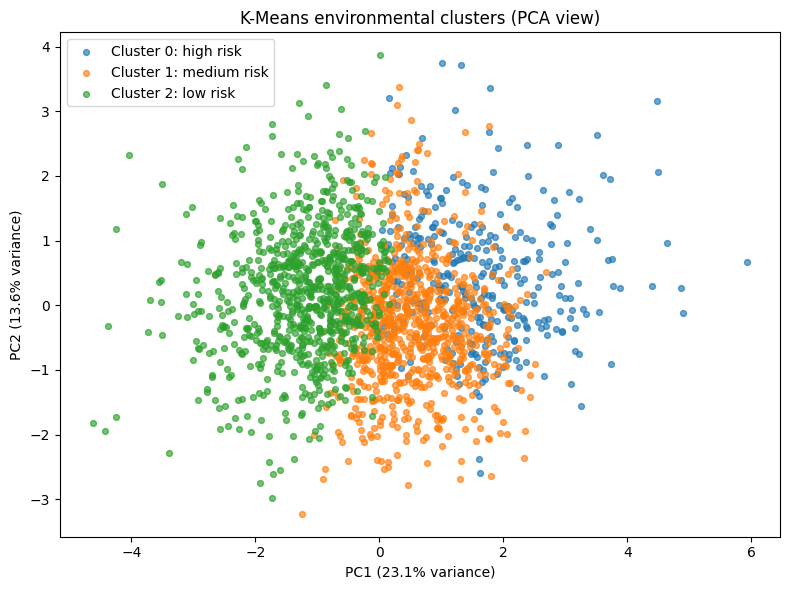

In [12]:
# Project the environmental data into two principal components and plot a reproducible subset colored by cluster.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(feature_data)
plot_size = min(SELECTION_SAMPLE_SIZE, len(df))
plot_positions = np.random.default_rng(RANDOM_STATE).choice(
    len(df), size=plot_size, replace=False
)

figure, axis = plt.subplots(figsize=(8, 6))
for cluster_id in sorted(cluster_risk_labels):
    cluster_mask = df[CLUSTER_COLUMN].to_numpy() == cluster_id
    selected_positions = plot_positions[cluster_mask[plot_positions]]
    axis.scatter(
        pca_coordinates[selected_positions, 0],
        pca_coordinates[selected_positions, 1],
        alpha=0.65,
        s=18,
        label=f"Cluster {cluster_id}: {cluster_risk_labels[cluster_id]} risk",
    )

explained = pca.explained_variance_ratio_
axis.set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
axis.set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
axis.set_title("K-Means environmental clusters (PCA view)")
axis.legend()
figure.tight_layout()
plt.show()

## Review the Result

Review cluster sizes, feature means, relative-risk ordering, and the PCA plot. The risk names depend on the supplied dataset and the stated heuristic; document unusual or overlapping clusters before proceeding to classification.

In [13]:
# Summarize the final assignments and report the project artifacts created by this notebook.
cluster_counts = df[CLUSTER_COLUMN].value_counts().sort_index()
print(f"Rows clustered: {len(df)}")
print("Cluster sizes:")
for cluster_id, row_count in cluster_counts.items():
    print(f"- Cluster {cluster_id} ({cluster_risk_labels[cluster_id]} risk): {row_count} rows")
print("Saved feature order:", MODEL_FEATURE_COLUMNS)
print("Interpretation is relative and heuristic; validate it against observed flood labels during evaluation.")

Rows clustered: 3000
Cluster sizes:
- Cluster 0 (high risk): 501 rows
- Cluster 1 (medium risk): 1275 rows
- Cluster 2 (low risk): 1224 rows
Saved feature order: ['rainfall', 'soil_moisture', 'humidity', 'ndvi', 'ndwi', 'elevation', 'slope', 'temperature', 'cluster_label']
Interpretation is relative and heuristic; validate it against observed flood labels during evaluation.
